# Khoa học Dữ liệu (Data Science)
## Với ứng dụng trong Tài chính định lượng (With Quant Finance Applications)

### Giới thiệu môn học
- **Mã môn**: INT xxxx
- **Số tín chỉ**: 3
- **Mục tiêu**: Nắm vững các khái niệm, phương pháp và công cụ trong Khoa học Dữ liệu
- **Focus**: Ứng dụng thực tế trong Tài chính định lượng (Quantitative Finance)

In [ ]:
# Setup - Run this first
%pip install scikit-learn numpy pandas matplotlib scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Quant Finance style
plt.style.use('dark_background')
np.random.seed(42)

print('Libraries loaded successfully!')

Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully!


---
## Chương 1: Thống kê mô tả (Descriptive Statistics)

### Ứng dụng Quant Finance:
- **Mean**: Trung bình lợi nhuận hàng ngày của cổ phiếu
- **Std Dev (Volatility)**: Đo lường rủi ro
- **Median**: Lợi nhuận trung vị (robust với outliers)

### 📝 Các công thức quan trọng (Key Formulas)

*   **Mean (Trung bình cộng):**
    $$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$
    *   **Quant Finance Use**: Tính expected return của portfolio
    *   **Variables**: $\bar{x}$: Mean return, $x_i$: Daily returns

*   **Volatility (Độ biến động):**
    $$\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$$
    *   **Quant Finance Use**: Annualized volatility (252 trading days/year)
    *   **Variables**: $\sigma$: Standard deviation of returns

In [21]:
# DEMO: Stock Returns Analysis
# Simulate 1 year of daily returns for a stock

daily_returns = np.random.normal(0.0005, 0.02, 252)  # mean=0.05%, std=2%

# Descriptive Statistics
mean_return = np.mean(daily_returns)
std_dev = np.std(daily_returns)
median_return = np.median(daily_returns)
annualized_vol = std_dev * np.sqrt(252)
annualized_return = mean_return * 252

print('=== Stock Return Statistics ===')
print(f'Mean Daily Return:     {mean_return:.4%}')
print(f'Daily Volatility:      {std_dev:.4%}')
print(f'Median Daily Return:   {median_return:.4%}')
print(f'---')
print(f'Annualized Return:     {annualized_return:.2%}')
print(f'Annualized Volatility: {annualized_vol:.2%}')
print(f'Sharpe Ratio (rf=0):   {annualized_return/annualized_vol:.2f}')

=== Stock Return Statistics ===
Mean Daily Return:     0.0425%
Daily Volatility:      1.9306%
Median Daily Return:   0.1684%
---
Annualized Return:     10.70%
Annualized Volatility: 30.65%
Sharpe Ratio (rf=0):   0.35


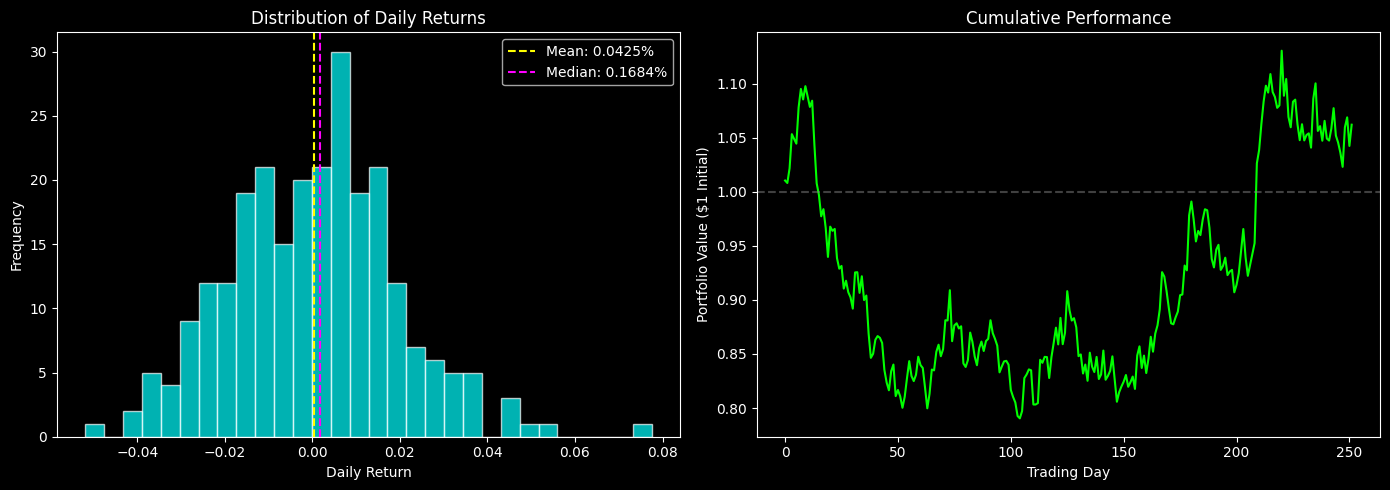

In [22]:
# Visualization: Return Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(daily_returns, bins=30, alpha=0.7, color='cyan', edgecolor='white')
axes[0].axvline(mean_return, color='yellow', linestyle='--', label=f'Mean: {mean_return:.4%}')
axes[0].axvline(median_return, color='magenta', linestyle='--', label=f'Median: {median_return:.4%}')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily Returns')
axes[0].legend()

# Cumulative Returns
cumulative = (1 + daily_returns).cumprod()
axes[1].plot(cumulative, color='lime')
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Portfolio Value ($1 Initial)')
axes[1].set_title('Cumulative Performance')
axes[1].axhline(1, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## Chương 2: Xác suất (Probability Theory)

### Ứng dụng Quant Finance:
- **Bayes' Theorem**: Cập nhật xác suất sự kiện thị trường
- **Expected Value**: Tính kỳ vọng lợi nhuận của chiến lược

### 📝 Các công thức quan trọng (Key Formulas)

*   **Bayes' Theorem:**
    $$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$
    *   **Quant Finance Use**: P(Market Up | Positive Earnings) - cập nhật dự đoán khi có tin mới

*   **Expected Value của Strategy:**
    $$E[PnL] = P(win) \times Avg\_Win - P(loss) \times Avg\_Loss$$
    *   **Quant Finance Use**: Đánh giá edge của trading strategy

In [23]:
# DEMO: Bayes Theorem - Updating Market Prediction
# Scenario: Predicting market direction after earnings

# Prior: P(Market Up) based on historical data
P_up = 0.55  # 55% of days are up days
P_down = 0.45

# Likelihoods: P(Positive Earnings | Market Direction)
P_pos_given_up = 0.70   # When market up, 70% earnings are positive
P_pos_given_down = 0.30 # When market down, 30% earnings still positive

# We observe: Positive earnings report
# Calculate: P(Market Up | Positive Earnings)

# Total probability of positive earnings
P_positive = P_pos_given_up * P_up + P_pos_given_down * P_down

# Bayes' Theorem
P_up_given_positive = (P_pos_given_up * P_up) / P_positive

print('=== Bayes Theorem: Market Prediction ===' )
print(f'Prior P(Market Up):              {P_up:.2%}')
print(f'P(Positive Earnings):            {P_positive:.2%}')
print(f'---')
print(f'POSTERIOR: P(Up | Pos Earnings): {P_up_given_positive:.2%}')
print(f'Edge gained from information:    +{(P_up_given_positive - P_up)*100:.1f} percentage points')

=== Bayes Theorem: Market Prediction ===
Prior P(Market Up):              55.00%
P(Positive Earnings):            52.00%
---
POSTERIOR: P(Up | Pos Earnings): 74.04%
Edge gained from information:    +19.0 percentage points


In [24]:
# DEMO: Expected Value of a Trading Strategy

# Strategy parameters
win_rate = 0.45       # Win 45% of trades
avg_win = 2.5         # Average win: 2.5R (Risk units)
avg_loss = 1.0        # Average loss: 1R
trades_per_year = 100
risk_per_trade = 1000  # $1000 per trade

# Expected Value per trade (in R)
expected_R = win_rate * avg_win - (1 - win_rate) * avg_loss

# Annual expected profit
annual_expected = expected_R * trades_per_year * risk_per_trade

print('=== Trading Strategy Expected Value ===')
print(f'Win Rate:           {win_rate:.0%}')
print(f'Average Win:        {avg_win:.1f}R')
print(f'Average Loss:       {avg_loss:.1f}R')
print(f'---')
print(f'Expected Value/Trade: {expected_R:.2f}R')
print(f'Risk/Trade:           ${risk_per_trade:,.0f}')
print(f'Annual Expected PnL:  ${annual_expected:,.0f}')
print(f'---')
print(f'Edge: {"POSITIVE" if expected_R > 0 else "NEGATIVE"}')

=== Trading Strategy Expected Value ===
Win Rate:           45%
Average Win:        2.5R
Average Loss:       1.0R
---
Expected Value/Trade: 0.57R
Risk/Trade:           $1,000
Annual Expected PnL:  $57,500
---
Edge: POSITIVE


---
## Chương 3: Phân phối xác suất (Probability Distributions)

### Ứng dụng Quant Finance:
- **Normal Distribution**: Mô hình hóa log returns
- **Fat Tails**: Thực tế returns có đuôi dày hơn Normal
- **VaR (Value at Risk)**: Sử dụng quantile của distribution

### 📝 Các công thức quan trọng (Key Formulas)

*   **Value at Risk (VaR):**
    $$VaR_{\alpha} = \mu - z_{\alpha} \cdot \sigma$$
    *   **Quant Finance Use**: Maximum expected loss at confidence level $\alpha$
    *   **Variables**: $z_{\alpha}$ = 1.65 for 95% VaR, 2.33 for 99% VaR

*   **Black-Scholes uses log-normal:**
    $$S_T = S_0 \cdot e^{(\mu - \frac{\sigma^2}{2})T + \sigma\sqrt{T}Z}$$
    *   **Quant Finance Use**: Option pricing assumes log-normal stock prices

In [25]:
# DEMO: Value at Risk (VaR) Calculation

portfolio_value = 1_000_000  # $1M portfolio
daily_vol = 0.015            # 1.5% daily volatility
mean_return = 0.0003         # 0.03% daily return

# Parametric VaR (assuming normal distribution)
confidence_levels = [0.95, 0.99]

print('=== Value at Risk (VaR) Analysis ===')
print(f'Portfolio Value: ${portfolio_value:,.0f}')
print(f'Daily Volatility: {daily_vol:.2%}')
print(f'---')

for conf in confidence_levels:
    z_score = stats.norm.ppf(1 - conf)  # Left tail
    var_pct = mean_return + z_score * daily_vol
    var_dollar = abs(var_pct) * portfolio_value
    print(f'{conf:.0%} VaR (1-day): ${var_dollar:,.0f} ({abs(var_pct):.2%})')

# 10-day VaR (square root of time)
z_99 = stats.norm.ppf(0.01)
var_10day = abs(mean_return * 10 + z_99 * daily_vol * np.sqrt(10)) * portfolio_value
print(f'99% VaR (10-day): ${var_10day:,.0f}')

=== Value at Risk (VaR) Analysis ===
Portfolio Value: $1,000,000
Daily Volatility: 1.50%
---
95% VaR (1-day): $24,373 (2.44%)
99% VaR (1-day): $34,595 (3.46%)
99% VaR (10-day): $107,348


Probability of -5% or worse:
  Normal:     0.670%
  Fat-Tailed: 1.010% (1.5x more likely!)


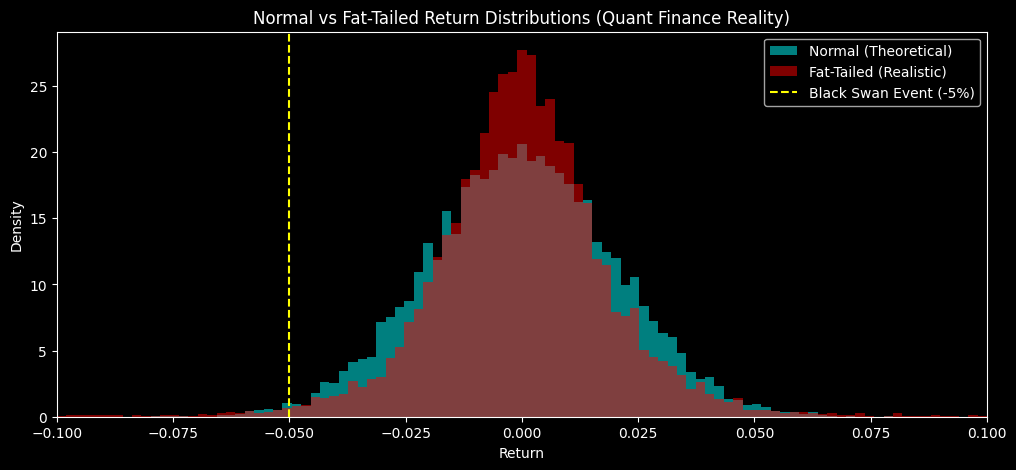

In [26]:
# Visualization: Normal vs Fat-Tailed Returns
n_samples = 10000

# Normal returns
normal_returns = np.random.normal(0, 0.02, n_samples)

# Fat-tailed returns (Student's t with df=4)
t_returns = np.random.standard_t(df=4, size=n_samples) * 0.02 / np.sqrt(4/(4-2))

fig, ax = plt.subplots(figsize=(12, 5))

# Histogram
bins = np.linspace(-0.1, 0.1, 100)
ax.hist(normal_returns, bins=bins, alpha=0.5, color='cyan', label='Normal (Theoretical)', density=True)
ax.hist(t_returns, bins=bins, alpha=0.5, color='red', label='Fat-Tailed (Realistic)', density=True)

# Mark extreme events
ax.axvline(-0.05, color='yellow', linestyle='--', label='Black Swan Event (-5%)')

ax.set_xlabel('Return')
ax.set_ylabel('Density')
ax.set_title('Normal vs Fat-Tailed Return Distributions (Quant Finance Reality)')
ax.legend()
ax.set_xlim(-0.1, 0.1)

# Calculate tail probabilities
normal_tail = np.mean(normal_returns < -0.05) * 100
fat_tail = np.mean(t_returns < -0.05) * 100
print(f'Probability of -5% or worse:')
print(f'  Normal:     {normal_tail:.3f}%')
print(f'  Fat-Tailed: {fat_tail:.3f}% ({fat_tail/normal_tail:.1f}x more likely!)')

plt.show()

---
## Chương 4: Hồi quy tuyến tính (Linear Regression)

### Ứng dụng Quant Finance:
- **CAPM Beta**: Regression của stock returns vs market returns
- **Factor Models**: Fama-French 3/5 factor regression
- **Pairs Trading**: Cointegration regression

### 📝 Các công thức quan trọng (Key Formulas)

*   **CAPM Model:**
    $$R_i - R_f = \alpha + \beta (R_m - R_f) + \epsilon$$
    *   **Variables**: $\beta$ = sensitivity to market, $\alpha$ = excess return (skill)
    *   **Quant Finance Use**: Measuring systematic risk and stock-picking skill

*   **Fama-French 3-Factor:**
    $$R_i - R_f = \alpha + \beta_{mkt}MKT + \beta_{smb}SMB + \beta_{hml}HML + \epsilon$$
    *   **Quant Finance Use**: Decomposing returns into size and value factors

In [27]:
# DEMO: CAPM Beta Calculation
from scipy.stats import linregress

# Simulate market and stock returns (252 trading days)
n_days = 252
market_returns = np.random.normal(0.0004, 0.012, n_days)  # SPY-like

# Stock with beta=1.5, alpha=0.0002 (positive alpha!)
true_beta = 1.5
true_alpha = 0.0002  # Daily alpha
stock_returns = true_alpha + true_beta * market_returns + np.random.normal(0, 0.008, n_days)

# Run regression
slope, intercept, r_value, p_value, std_err = linregress(market_returns, stock_returns)

print('=== CAPM Regression (R_stock = alpha + beta * R_market) ===')
print(f'Beta (slope):    {slope:.3f} (true: {true_beta})')
print(f'Alpha (daily):   {intercept:.5f} ({intercept*252:.2%} annualized)')
print(f'R-squared:       {r_value**2:.3f}')
print(f'---')
print(f'Interpretation:')
print(f'  - Stock moves {slope:.1f}x the market')
print(f'  - Alpha > 0 suggests manager skill: {"YES" if intercept > 0 else "NO"}')

=== CAPM Regression (R_stock = alpha + beta * R_market) ===
Beta (slope):    1.490 (true: 1.5)
Alpha (daily):   0.00119 (29.91% annualized)
R-squared:       0.849
---
Interpretation:
  - Stock moves 1.5x the market
  - Alpha > 0 suggests manager skill: YES


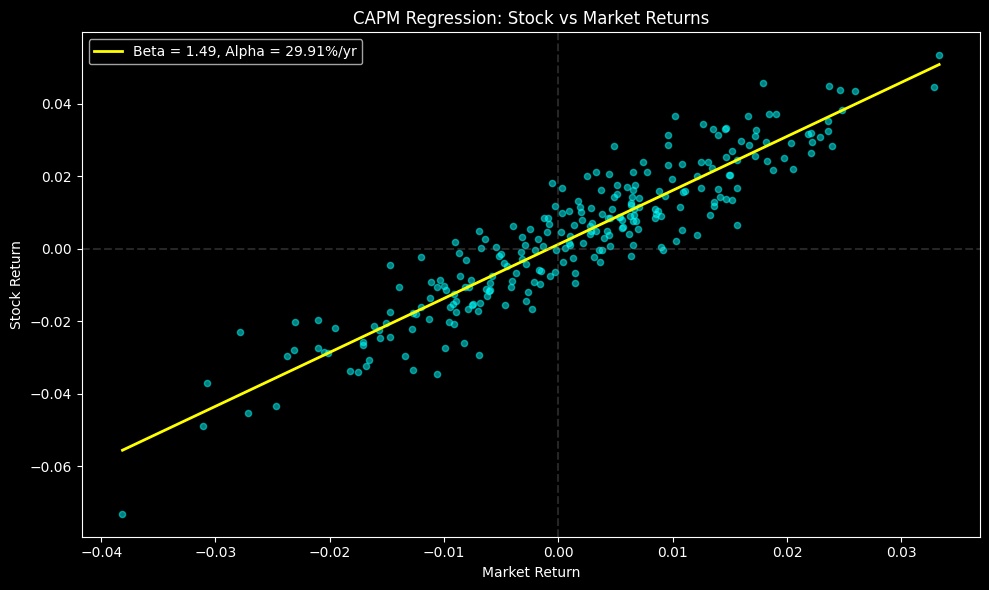

In [28]:
# Visualization: CAPM Scatter Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(market_returns, stock_returns, alpha=0.5, color='cyan', s=20)

# Regression line
x_line = np.linspace(market_returns.min(), market_returns.max(), 100)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color='yellow', linewidth=2, 
        label=f'Beta = {slope:.2f}, Alpha = {intercept*252:.2%}/yr')

ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Market Return')
ax.set_ylabel('Stock Return')
ax.set_title('CAPM Regression: Stock vs Market Returns')
ax.legend()

plt.tight_layout()
plt.show()

---
## Chương 5: Phân loại (Classification)

### Ứng dụng Quant Finance:
- **Market Direction Prediction**: Up/Down classification
- **Credit Scoring**: Default/No-default prediction
- **Fraud Detection**: Anomaly classification

### 📝 Các công thức quan trọng (Key Formulas)

*   **Logistic Regression for Trading:**
    $$P(Up_{tomorrow}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 \cdot RSI + \beta_2 \cdot Momentum + ...)}}$$
    *   **Quant Finance Use**: Probability of market direction

*   **Kelly Criterion (using probabilities):**
    $$f^* = \frac{p \cdot b - q}{b}$$
    *   **Variables**: $p$ = win probability, $b$ = odds, $q$ = 1-p
    *   **Quant Finance Use**: Optimal position sizing from classification output

In [29]:
# DEMO: Market Direction Classifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Generate features and labels
n_samples = 1000

# Features: RSI, Momentum, Volatility
rsi = np.random.uniform(20, 80, n_samples)
momentum = np.random.normal(0, 1, n_samples)
volatility = np.random.uniform(0.01, 0.04, n_samples)

# True relationship (with noise)
linear_combo = 0.02 * (rsi - 50) + 0.5 * momentum - 10 * volatility + np.random.normal(0, 1, n_samples)
y = (linear_combo > 0).astype(int)  # 1 = Up, 0 = Down

X = np.column_stack([rsi, momentum, volatility])

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('=== Market Direction Classifier ===')
print('Features: RSI, Momentum, Volatility')
print('Target: Next Day Direction (1=Up, 0=Down)')
print('---')
print(f'Accuracy: {(y_pred == y_test).mean():.2%}')
print(f'\nCoefficients:')
print(f'  RSI:        {model.coef_[0][0]:.4f}')
print(f'  Momentum:   {model.coef_[0][1]:.4f}')
print(f'  Volatility: {model.coef_[0][2]:.4f}')

=== Market Direction Classifier ===
Features: RSI, Momentum, Volatility
Target: Next Day Direction (1=Up, 0=Down)
---
Accuracy: 66.33%

Coefficients:
  RSI:        0.0289
  Momentum:   0.6832
  Volatility: -0.0481


In [30]:
# DEMO: Kelly Criterion from Classification

def kelly_bet(win_prob, win_loss_ratio):
    """Calculate Kelly optimal fraction"""
    q = 1 - win_prob
    return (win_prob * win_loss_ratio - q) / win_loss_ratio

# Simulated prediction probabilities
predictions = y_prob
win_loss_ratio = 1.5  # Average win is 1.5x average loss

# Calculate Kelly for each prediction
kelly_fractions = [kelly_bet(p, win_loss_ratio) for p in predictions]

print('=== Kelly Criterion Position Sizing ===')
print(f'Win/Loss Ratio: {win_loss_ratio}')
print('---')
print('Sample predictions and Kelly bet sizes:')
for i in range(5):
    kelly = kelly_fractions[i]
    action = 'BET' if kelly > 0 else 'SKIP'
    print(f'  P(Up)={predictions[i]:.2%} -> Kelly={kelly:.2%} -> {action}')

=== Kelly Criterion Position Sizing ===
Win/Loss Ratio: 1.5
---
Sample predictions and Kelly bet sizes:
  P(Up)=59.77% -> Kelly=32.94% -> BET
  P(Up)=36.30% -> Kelly=-6.17% -> SKIP
  P(Up)=25.25% -> Kelly=-24.58% -> SKIP
  P(Up)=62.51% -> Kelly=37.52% -> BET
  P(Up)=40.03% -> Kelly=0.06% -> BET


---
## Chương 6: Phân cụm (Clustering)

### Ứng dụng Quant Finance:
- **Market Regime Detection**: Bull/Bear/Sideways regimes
- **Asset Clustering**: Grouping correlated assets
- **Investor Segmentation**: Clustering trading behaviors

=== Market Regime Detection ===
Clustering on: Return, Volatility
---
Regime Characteristics:
  Regime 0: Return=309.9%, Vol=21.6% -> BULL
  Regime 1: Return=-1043.3%, Vol=41.2% -> BEAR
  Regime 2: Return=-152.9%, Vol=18.8% -> BEAR

=== Visualization ===


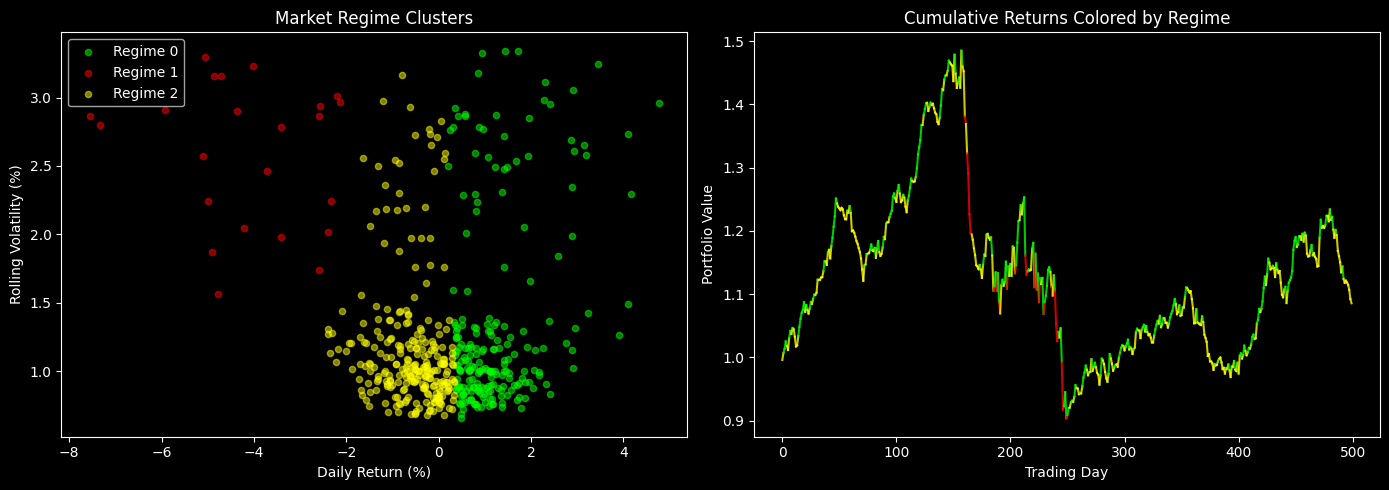

In [31]:
# DEMO: Market Regime Detection with K-Means
from sklearn.cluster import KMeans

# Simulate market data with different regimes
n_days = 500

# Features: Daily return, Volatility (rolling 20-day)
returns = np.concatenate([
    np.random.normal(0.002, 0.008, 150),   # Bull market: high return, low vol
    np.random.normal(-0.001, 0.025, 100),  # Crisis: negative return, high vol
    np.random.normal(0.0005, 0.01, 150),   # Sideways: low return, medium vol
    np.random.normal(0.0015, 0.012, 100),  # Recovery: moderate
])

# Rolling volatility (simplified)
volatility = pd.Series(returns).rolling(20).std().fillna(0.01).values

# Cluster
X = np.column_stack([returns, volatility])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
regimes = kmeans.fit_predict(X)

print('=== Market Regime Detection ===')
print('Clustering on: Return, Volatility')
print('---')
print('Regime Characteristics:')
for i in range(3):
    mask = regimes == i
    avg_ret = returns[mask].mean() * 252  # Annualized
    avg_vol = volatility[mask].mean() * np.sqrt(252)
    regime_name = 'BULL' if avg_ret > 0.10 else 'BEAR' if avg_ret < 0 else 'SIDEWAYS'
    print(f'  Regime {i}: Return={avg_ret:.1%}, Vol={avg_vol:.1%} -> {regime_name}')

print('\n=== Visualization ===')
# Visualization: Market Regimes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of regimes
colors = ['lime', 'red', 'yellow']
for i in range(3):
    mask = regimes == i
    axes[0].scatter(returns[mask]*100, volatility[mask]*100, 
                    c=colors[i], alpha=0.5, s=20, label=f'Regime {i}')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Rolling Volatility (%)')
axes[0].set_title('Market Regime Clusters')
axes[0].legend()

# Time series with regime colors
cumulative = (1 + returns).cumprod()
for i in range(len(cumulative) - 1):
    axes[1].plot([i, i+1], [cumulative[i], cumulative[i+1]], 
                 color=colors[regimes[i]], alpha=0.8)
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Portfolio Value')
axes[1].set_title('Cumulative Returns Colored by Regime')

plt.tight_layout()
plt.show()

In [32]:
# Visualization moved to previous cell to avoid dependency errors
print('Visualization has been generated in the previous cell.')

Visualization has been generated in the previous cell.


---
## Chương 7: Giảm chiều dữ liệu (PCA)

### Ứng dụng Quant Finance:
- **Factor Extraction**: Tìm hidden factors từ returns
- **Portfolio Construction**: Statistical arbitrage
- **Risk Decomposition**: Hiểu nguồn rủi ro

In [33]:
# DEMO: PCA on Stock Returns (Factor Extraction)
from sklearn.decomposition import PCA

# Simulate 10 stocks with correlated returns (driven by 2 hidden factors)
n_days = 252
n_stocks = 10

# Hidden factors
market_factor = np.random.normal(0, 0.012, n_days)  # Market
sector_factor = np.random.normal(0, 0.008, n_days)  # Sector

# Stock returns = combination of factors + noise
betas_market = np.random.uniform(0.5, 1.5, n_stocks)
betas_sector = np.random.uniform(-0.5, 0.5, n_stocks)

stock_returns = np.zeros((n_days, n_stocks))
for i in range(n_stocks):
    stock_returns[:, i] = (betas_market[i] * market_factor + 
                           betas_sector[i] * sector_factor + 
                           np.random.normal(0, 0.005, n_days))

# Apply PCA
pca = PCA()
pca.fit(stock_returns)

print('=== PCA on Stock Returns ===')
print(f'Number of stocks: {n_stocks}')
print(f'---')
print('Explained Variance by Component:')
cumulative = 0
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    cumulative += var
    print(f'  PC{i+1}: {var:.1%} (Cumulative: {cumulative:.1%})')

print(f'---')
print(f'First 2 PCs explain {pca.explained_variance_ratio_[:2].sum():.1%} of variance')
print(f'Interpretation: ~2 hidden factors drive most returns')

=== PCA on Stock Returns ===
Number of stocks: 10
---
Explained Variance by Component:
  PC1: 89.5% (Cumulative: 89.5%)
  PC2: 2.7% (Cumulative: 92.2%)
  PC3: 1.2% (Cumulative: 93.4%)
  PC4: 1.2% (Cumulative: 94.6%)
  PC5: 1.1% (Cumulative: 95.7%)
---
First 2 PCs explain 92.2% of variance
Interpretation: ~2 hidden factors drive most returns


---
## Chương 8: Mean-Variance Optimization (Markowitz)

### Ứng dụng Quant Finance:
- **Efficient Frontier**: Tìm portfolios tối ưu
- **Risk Parity**: Cân bằng contribution to risk

In [34]:
# DEMO: Mean-Variance Optimization (Markowitz)

# Asset parameters (annualized)
assets = ['Stocks', 'Bonds', 'Gold']
expected_returns = np.array([0.10, 0.04, 0.06])  # 10%, 4%, 6%
volatilities = np.array([0.20, 0.05, 0.15])      # 20%, 5%, 15%
correlations = np.array([
    [1.0, 0.2, 0.0],   # Stocks vs others
    [0.2, 1.0, -0.1],  # Bonds vs others
    [0.0, -0.1, 1.0],  # Gold vs others
])

# Convert to covariance matrix
cov_matrix = np.outer(volatilities, volatilities) * correlations

# Generate random portfolios
n_portfolios = 5000
results = np.zeros((n_portfolios, 4))  # ret, vol, sharpe, weights

for i in range(n_portfolios):
    weights = np.random.random(3)
    weights /= weights.sum()
    
    port_return = weights @ expected_returns
    port_vol = np.sqrt(weights @ cov_matrix @ weights)
    sharpe = port_return / port_vol
    
    results[i, :3] = [port_return, port_vol, sharpe]

# Find optimal portfolio (max Sharpe)
max_sharpe_idx = results[:, 2].argmax()

print('=== Markowitz Mean-Variance Optimization ===')
print('Assets:', assets)
print('---')
print(f'Max Sharpe Portfolio:')
print(f'  Expected Return: {results[max_sharpe_idx, 0]:.2%}')
print(f'  Volatility:      {results[max_sharpe_idx, 1]:.2%}')
print(f'  Sharpe Ratio:    {results[max_sharpe_idx, 2]:.2f}')

=== Markowitz Mean-Variance Optimization ===
Assets: ['Stocks', 'Bonds', 'Gold']
---
Max Sharpe Portfolio:
  Expected Return: 4.82%
  Volatility:      4.86%
  Sharpe Ratio:    0.99


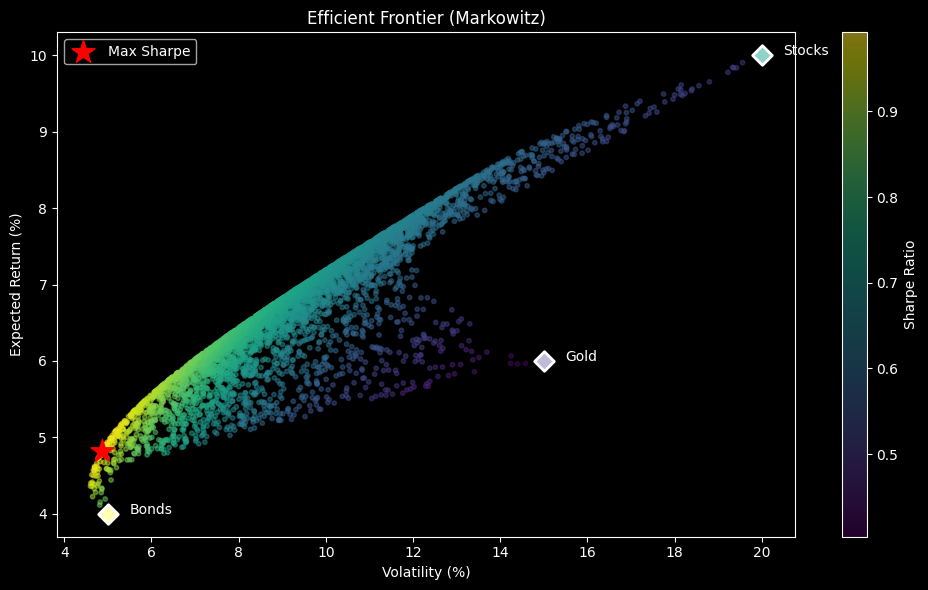

: 

In [ ]:
# Visualization: Efficient Frontier
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter of all portfolios, colored by Sharpe
scatter = ax.scatter(results[:, 1]*100, results[:, 0]*100, 
                     c=results[:, 2], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')

# Mark max Sharpe
ax.scatter(results[max_sharpe_idx, 1]*100, results[max_sharpe_idx, 0]*100,
           c='red', marker='*', s=300, label='Max Sharpe')

# Mark individual assets
for i, asset in enumerate(assets):
    ax.scatter(volatilities[i]*100, expected_returns[i]*100, 
               marker='D', s=100, edgecolors='white', linewidth=2)
    ax.annotate(asset, (volatilities[i]*100 + 0.5, expected_returns[i]*100))

ax.set_xlabel('Volatility (%)')
ax.set_ylabel('Expected Return (%)')
ax.set_title('Efficient Frontier (Markowitz)')
ax.legend()

plt.tight_layout()
plt.show()

---
# Tóm tắt nhanh (Quick Reference)

| Bài toán Quant | Thuật toán | Metric |
|----------------|------------|--------|
| Risk Measurement | Volatility, VaR | Std Dev, Quantile |
| Alpha Estimation | CAPM Regression | Alpha, R² |
| Direction Prediction | Logistic Regression | Accuracy, F1 |
| Regime Detection | K-Means Clustering | Silhouette |
| Factor Extraction | PCA | Explained Variance |
| Portfolio Optimization | Mean-Variance | Sharpe Ratio |